In [2]:
# Upgrade pip
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install numpy matplotlib seaborn # seaborn Makes prettier, easier chart ,mtplb for basic graphs (plots, charts)
#numpy,handles numbers and arrays fast

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost lightgbm # for Very powerful ML algorithm that gives high accuracy.Faster boosting model for large data

  Using cached xgboost-3.1.2-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 377.4 kB/s eta 0:03:10
   ---------------------------------------- 0.5/72.0 MB 377.4 kB/s eta 0:03:10
   ---------------------------------------- 0.5/72.0 MB 377.4 kB/s eta 0:03:10
   ---------------------------------------- 0.5/72.0 MB 377.4 kB/s eta 0:03:10
   ---------------------------------------- 0.5/72.0 MB 377.4 kB/s eta 0:03:10
   ---------------------------------------- 0

In [4]:
# Install imbalanced-learn and shape , it Handles imbalanced datasets (oversampling/undersampling).
pip install imbalanced-learn shape 

   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/38.9 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/38.9 MB 5.0 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.9 MB 5.3 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/38.9 MB 5.7 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/38.9 MB 5.7 MB/s eta 0:00:06
   ------ --------------------------------- 6.0/38.9 MB 4.8 MB/s eta 0:00:07
   ------- -------------------------------- 6.8/38.9 MB 4.4 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/38.9 MB 4.2 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/38.9 MB 4.1 MB/s eta 0:00:08
   --------- ------------------------------ 9.2/38.9 MB 4.1 MB/s eta 0:00:08
   --------- ------------------------------ 9.7/38.9 MB 4.0 MB/s eta 0:00:08
   ----------

In [1]:
#Import pandas
import pandas as pd

In [2]:
# 1.load and inspect the data
train =pd.read_csv("datasets/aug_train.csv")
test =pd.read_csv("datasets/aug_test.csv")
#clean the data 
print("test",test.shape)
print("train",train.shape)
display(train.head)
train.info()
print(train.isna().sum()
.sort_values(ascending=False).head(20))   #Checks every cell and marks True if the value is missing (NaN), else False.


test (2129, 13)
train (19158, 14)


<bound method NDFrame.head of        enrollee_id      city  city_development_index gender  \
0             8949  city_103                   0.920   Male   
1            29725   city_40                   0.776   Male   
2            11561   city_21                   0.624    NaN   
3            33241  city_115                   0.789    NaN   
4              666  city_162                   0.767   Male   
...            ...       ...                     ...    ...   
19153         7386  city_173                   0.878   Male   
19154        31398  city_103                   0.920   Male   
19155        24576  city_103                   0.920   Male   
19156         5756   city_65                   0.802   Male   
19157        23834   city_67                   0.855    NaN   

           relevent_experience enrolled_university education_level  \
0      Has relevent experience       no_enrollment        Graduate   
1       No relevent experience       no_enrollment        Graduate   
2  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [3]:
#Check target distributions
train['target'].value_counts()    #Counts how many times each value (0 or 1)
train['target'].value_counts(normalize=True) #Gives the value in  percentage

target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64

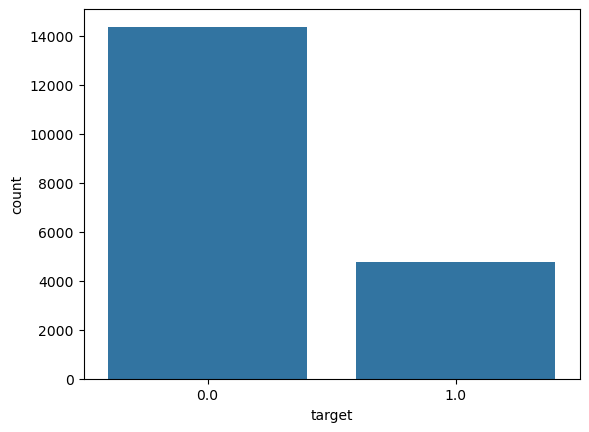

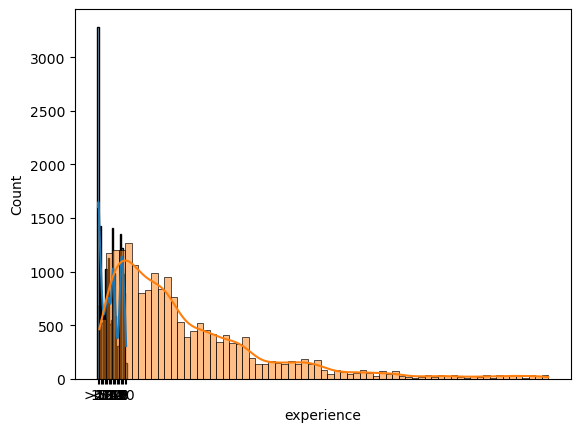

In [4]:
# 2. Exploratory data analysis (EDA)
import seaborn as sns         #seeabirn and matplot is used for geanarating graphs 
import matplotlib.pyplot as plt 

#bar chat
sns.countplot(x='target', data=train)
plt.show()

#histogram chart 
sns.histplot(train['experience'],kde= True); plt.show
sns.histplot(train['training_hours'],kde =True); plt.show()


In [5]:
# 3. Feature engineering
# a) ADD NEW FEATURES

print(" Adding new features...")

train['exp_training'] = train['experience'] * train['training_hours']    # exp_training: Product of experience and training hours.
test['exp_training'] = test['experience'] * test['training_hours']       #city_dev_training: Ratio of city development index to training hours.

train['city_dev_training'] = train['city_development_index'] / (train['training_hours'] + 1)
test['city_dev_training'] = test['city_development_index'] / (test['training_hours'] + 1)

print(f" Added 2 features")
print(f"Train shape: {train.shape}")

 Adding new features...
 Added 2 features
Train shape: (19158, 16)


In [6]:
#4.Data cleaning and preparation
# b) PREPARE DATA

print("\n Preparing data...")

# Fill missing values
train_filled = train.fillna('Unknown')  # replacing missing values with UNKNOWN
test_filled = test.fillna('Unknown')

# Separate features and target
X = train_filled.drop('target', axis=1)
y = train_filled['target']

# Remove ID column if exists
if 'enrollee_id' in X.columns:
    X = X.drop('enrollee_id', axis=1)
if 'enrollee_id' in test_filled.columns:
    test_filled = test_filled.drop('enrollee_id', axis=1)

print(" Data cleaned")



 Preparing data...
 Data cleaned


In [7]:
# 5. Data cleaning and preparation
# c)  ENCODE CATEGORICAL VARIABLES (FIXED)

print("\n🔤 Encoding categorical variables...")

# Fix: Clean the original data before get_dummies
# Remove any special characters that might cause issues
for df in [X, test_filled]:
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.replace('[\[\]<>]', '', regex=True)

# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)
test_encoded = pd.get_dummies(test_filled, drop_first=True)

# Fix: Ensure unique column names
X_encoded.columns = [f"col_{i}" for i in range(X_encoded.shape[1])]      # One-hot encodes categorical variables and renames columns to avoid XGBoost compatibility issues.
test_encoded.columns = [f"col_{i}" for i in range(test_encoded.shape[1])]

print(f"✓ Encoded: {X_encoded.shape[1]} features")
print(f"Train shape: {X_encoded.shape}")
print(f"Test shape: {test_encoded.shape}")
print("\nNote: Using simple column names to avoid XGBoost errors")


🔤 Encoding categorical variables...
✓ Encoded: 3619 features
Train shape: (19158, 3619)
Test shape: (2129, 1478)

Note: Using simple column names to avoid XGBoost errors


In [8]:
# d) APPLY SMOTE (BALANCE CLASSES)

from imblearn.over_sampling import SMOTE

print(" Balancing classes with SMOTE...")
print(f"Before - Class 0: {sum(y == 0):,}, Class 1: {sum(y == 1):,}")

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_encoded, y)

print(f"After - Class 0: {sum(y_balanced == 0):,}, Class 1: {sum(y_balanced == 1):,}")
print("✓ Classes balanced!")


 Balancing classes with SMOTE...
Before - Class 0: 14,381, Class 1: 4,777
After - Class 0: 14,381, Class 1: 14,381
✓ Classes balanced!


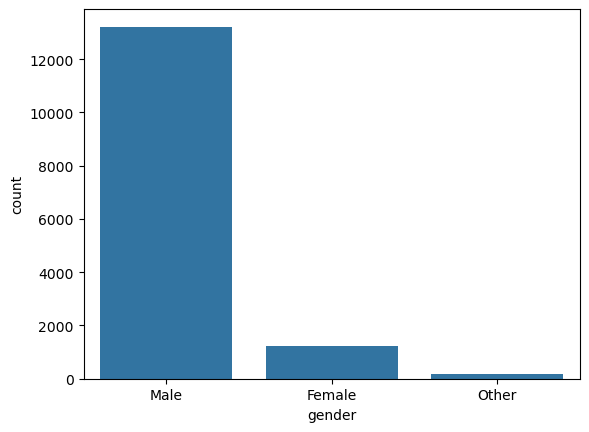

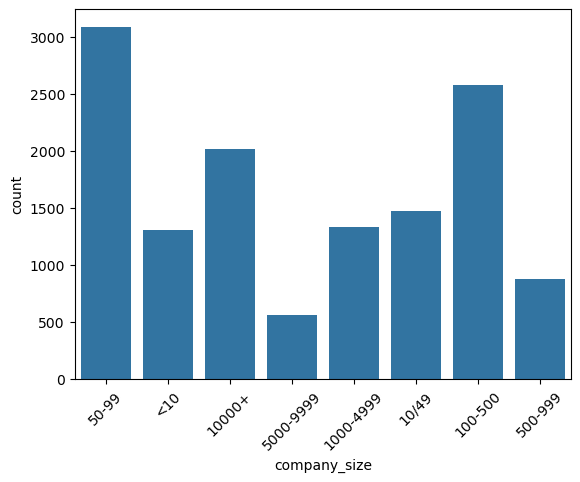

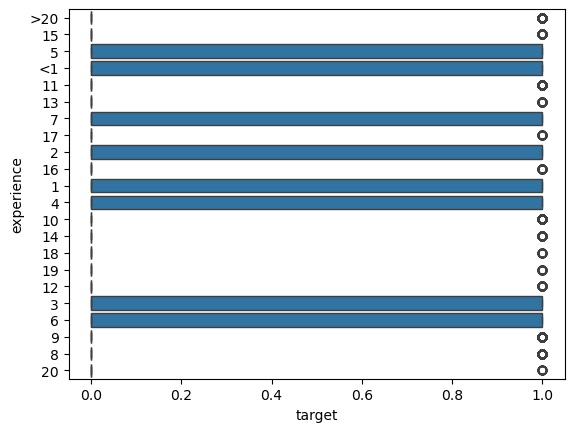

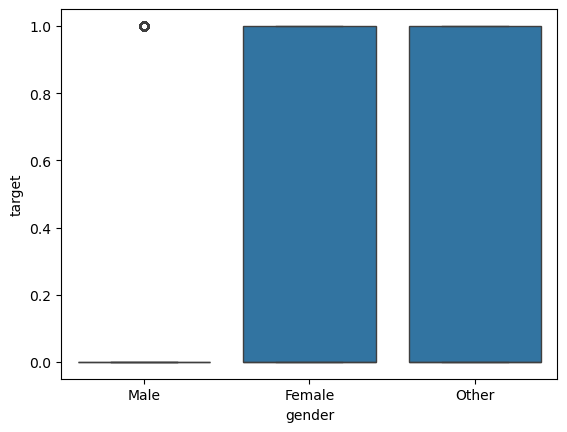

In [9]:
# checking data cleaning with EDA
#categorical distributions
sns.countplot(x='gender', data=train);plt.show()
sns.countplot(x='company_size',data=train);plt.xticks(rotation=45);plt.show()
#show how many people fall into each category

#relationship with target
sns.boxplot(x='target',y='experience',data=train);plt.show() 
sns.boxplot(x='gender',y='target',data=train);plt.show()   #how many males/females belong to each target class
#Creates a boxplot comparing experience values for each target class (0 vs 1)

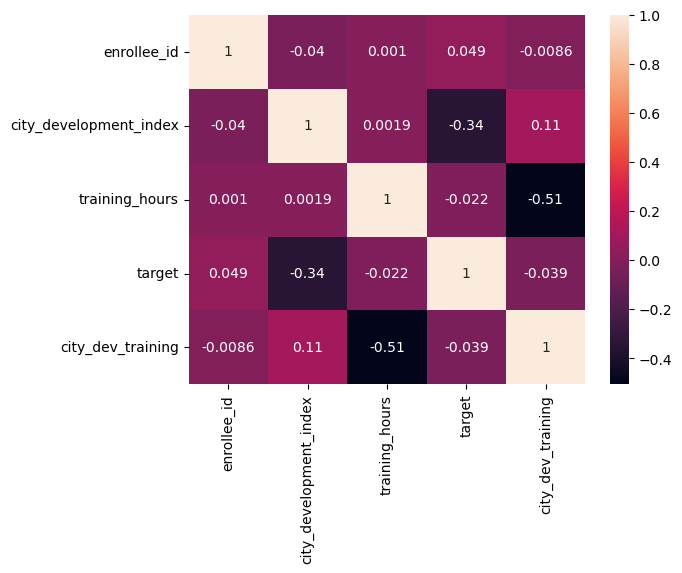

In [10]:
#more EDA after data cleaning
sns.heatmap(train.select_dtypes(include='number').corr() ,annot=True)       #.corr()=rComputes the correlation matrix
plt.show()
#hepls to quickly find which numeric features are strongly positively/negatively

In [11]:
#6.cleaning the data using functon 
#we create a fuction to in the experince column
def clean_experience(X):
    if pd.isna(X):return None             # find the null values and return the none in empty cell
    if str(X).strip()=='<1':return 0.0    # return will resend the datat in dataframe
    if str(X).strip()==">20":return 21.0
    try :return float(X)                   #Convert numeric values to float.
    except: return None

In [13]:
#we create a fuction to in the lastnewjob column
def clean_last_new_job(X):
    if pd.isna(X):return None 
    if str(X).strip()==  'never': return 0.0  #str(x) → x ko string me convert karta hai
    if str(X).strip()== '>4': return 5.0      #.strip() → starting aur ending ke spaces hata deta hai  
    try: return float(x)
    except: return None
    

In [14]:
# apply this above function in this cell (.apply)
if 'experience' in train.columns:
    train['experience'] = train['experience'].apply(clean_experience)
if 'last_new_job' in train.columns:
    train['last_new_job'] = train['last_new_job'].apply(clean_last_new_job)
if 'experience' in test.columns:
    test['experience'] = test['experience'].apply(clean_experience)
if 'last_new_job' in test.columns:
    test['last_new_job'] = test['last_new_job'].apply(clean_last_new_job)

#to see the result
print("train")
print(train[['experience', 'last_new_job']].head())
print("test")
print(test[['experience', 'last_new_job']].head())


train
   experience  last_new_job
0        21.0           NaN
1        15.0           5.0
2         5.0           0.0
3         0.0           0.0
4        21.0           NaN
test
   experience  last_new_job
0         9.0           NaN
1         5.0           NaN
2         0.0           0.0
3        11.0           NaN
4        21.0           5.0


In [15]:
#so now for prediction of empolyee main thing is age ,experience ,training hours ,etc 
#so now we are removing the unwanted "target","enrollee_id" columns so model can perform easly
X=train.drop(columns=["target","enrollee_id"])                          #.drop is used to delete the coulmns
num_cols=X.select_dtypes(include= ['int','float']).columns.tolist()     #x.select dtype will slect the columns which int and float values
cat_cols=X.select_dtypes(include=['object']).columns.tolist()       #object will select which name or alphbate and used for onehotencoder 
print(num_cols)
print(cat_cols)


['city_development_index', 'experience', 'last_new_job', 'training_hours', 'city_dev_training']
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type', 'exp_training']


In [16]:
#7.Preprocessing and Pipeline
# now we use preprocsing  pipeline to run multiple steps automatically in corect order
from sklearn.pipeline import Pipeline                            #  run multiple steps automatically 
from sklearn.compose import ColumnTransformer                    # .compose apply diff pipeline to num and idff for text
from sklearn.impute import SimpleImputer                         #fill missing value
from sklearn.preprocessing import OneHotEncoder,RobustScaler  # OneHotEncoder :convert text category to number lke city=delhi,mumbai 2 column
                                                       #RebustScaler : scale numbers but it safe when the number is verbig / very small
num_pipe= Pipeline([('impute',SimpleImputer(strategy='median')),    #"" simpleImputer will fill the mising value with medium ""
                    ('Scale',RobustScaler())])                       #"RobustScaler will scale numeric value 
cat_pipe= Pipeline([('impute',SimpleImputer(strategy='constant',fill_value='missing')), #Missing text → replace with "missing"
                    ('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]) # Convert text → OneHotEncoding (convert categories to 0/1 columns)
#combine the pipeline
preprocessor = ColumnTransformer([
    ('num',num_pipe,num_cols),                     #Apply num_pipe to numeric columns
    ('cat',cat_pipe,cat_cols)])                    #Apply cat_pipe to categorical columns

In [17]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

y = train['target']
X=train.drop(columns = ['target','enrollee_id'])  #we drop target and enrolleid ,so now x contains only feature
X_train, X_val, y_train, y_val=train_test_split(X , y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)  #x_train:tarining feature , X_val:testing feature
X_train.shape, X_val.shape
#test_size=0.2 → 20% data used for validation/test
#stratify=y → keeps target ratio same in train & test (important for classification)
#random_state=42 → same results every tim

((15326, 14), (3832, 14))

In [18]:
# 8. SELECTNG THE MODEL AND MODEL EVALUATION
#A special Python library (imb.learn)used when your dataset is imbalanced=imb
from imblearn.over_sampling import SMOTE                  #  SMOTE fills the gap between minority samples so both classes are balanced
smote=SMOTE(random_state=RANDOM_STATE)                    #SMOTE = creates smart fake data for the smaller class.

In [19]:
#so we first step to train the model using logistic regression
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression

pipe = ImbPipeline([('pre', preprocessor),
                    ('smote', smote),               # comment out 'smote' if data is balanced
                    ('clf', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scale',
                                                                   RobustScaler())]),
                                                  ['city_development_index',
                                                   'experience', 'last_new_job',
                                                   'training_hours',
                                                   'city_dev_training']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['city', 'gender',
                                                   'relevent_experience',
                                                   'enrolled_university',
                                                   'education_level',
                                                   'major_discipline',
                                                   'company_size',
                                                   'company_type',
                                                   'exp_training'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf', LogisticRegression(max_iter=1000))])

In [20]:
#evalueate logistic regression model
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
#import diff function to check how the model goos is ,each function measure performance in diff way

y_pred = pipe.predict(X_val)                     # sk the trained model to predict class labels (0 or 1) for validation data. 
y_proba= pipe.predict_proba(X_val)[:,1]          #Ask the model to give probabilities of class 1 
print("Accuracy :", accuracy_score(y_val, y_pred))  #Accuracy = % of correct predictions
print("precision :",precision_score(y_val, y_pred))  #When model says someone will leave, how correct is it
print("recall :",recall_score(y_val, y_pred))        # How many job-leavers did the model successfully find
print("f1_score :",f1_score(y_val, y_pred))          #F1 = Balance between precision & recall ,Good when data is imbalanced
print("ROC_AUC :",roc_auc_score(y_val, y_proba))      #How well the model separates class 0 and class 1
print("Confusion:",confusion_matrix(y_val, y_pred))  #confusionx matrix cal true positive,true nagative,false positive,false nagative


Accuracy : 0.7599164926931107
precision : 0.513267626990144
recall : 0.7089005235602094
f1_score : 0.5954265611257695
ROC_AUC : 0.7896039540897568
Confusion: [[2235  642]
 [ 278  677]]


In [21]:
#train model using random forest 

from sklearn.ensemble import RandomForestClassifier                 #Loads the Random Forest machine learning algorithm.
pipe_rf= ImbPipeline([('pre',preprocessor),
                      ('smote',smote),
                      ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])

pipe_rf.fit(X_train,y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scale',
                                                                   RobustScaler())]),
                                                  ['city_development_index',
                                                   'experience', 'last_new_job',
                                                   'training_hours',
                                                   'city_dev_training']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['city', 'gender',
                                                   'relevent_experience',
                                                   'enrolled_university',
                                                   'education_level',
                                                   'major_discipline',
                                                   'company_size',
                                                   'company_type',
                                                   'exp_training'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [22]:
#evaluate random forest model
y_pred_rf = pipe_rf.predict(X_val)    #predict the model
y_proba_rf= pipe_rf.predict_proba(X_val)[:,1] #find the probability of model 

print("rf_Accuracy :", accuracy_score(y_val, y_pred_rf))  #Accuracy = % of correct predictions
print("rf_precision :",precision_score(y_val, y_pred_rf))  #When model says someone will leave, how correct is it
print("rf_recall :",recall_score(y_val, y_pred_rf))        # How many job-leavers did the model successfully find
print("rf_f1_score :",f1_score(y_val, y_pred_rf))          #F1 = Balance between precision & recall ,Good when data is imbalanced
print("rf_ROC_AUC :",roc_auc_score(y_val, y_proba_rf))      #How well the model separates class 0 and class 1
print("rf_Confusion:",confusion_matrix(y_val, y_pred_rf))  #confusionx matrix cal true positive,true nagative,false positive,false nagative




rf_Accuracy : 0.7891440501043842
rf_precision : 0.5753846153846154
rf_recall : 0.587434554973822
rf_f1_score : 0.5813471502590674
rf_ROC_AUC : 0.8064537849381356
rf_Confusion: [[2463  414]
 [ 394  561]]


In [24]:

# training the model using XGBoost

print("\n Training XGBoost...")

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

#

# Convert to numpy arrays (no feature names)
X_train_np = X_train.values
X_val_np = X_val.values
y_train_np = y_train.values
y_val_np = y_val.values

# SIMPLIFIED XGBoost - removed use_label_encoder
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

# Train
xgb_model.fit(X_train_np, y_train_np)

# Validate
xgb_preds = xgb_model.predict_proba(X_val_np)[:, 1]
xgb_auc = roc_auc_score(y_val_np, xgb_preds)
xgb_acc = accuracy_score(y_val_np, (xgb_preds > 0.5).astype(int))
#adding confusion matrix
# Get predictions
xgb_val_preds = xgb_model.predict(X_val)
xgb_cm = confusion_matrix(y_val, xgb_val_preds)

print(f"\n📈 Validation Results:")
print(f"  AUC: {xgb_auc:.4f}")
print(f"  Accuracy: {xgb_acc:.4f}")
print("Confusion Matrix:")
print(f"[[TN={xgb_cm[0,0]}  FP={xgb_cm[0,1]}]")
print(f" [FN={xgb_cm[1,0]}  TP={xgb_cm[1,1]}]]")

print(" XGBoost trained successfully!")


 Training XGBoost...

📈 Validation Results:
  AUC: 0.9194
  Accuracy: 0.8448
Confusion Matrix:
[[TN=2381  FP=496]
 [FN=397  TP=2479]]
 XGBoost trained successfully!


[LightGBM] [Info] Number of positive: 11505, number of negative: 11504
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.079447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1851
[LightGBM] [Info] Number of data points in the train set: 23009, number of used features: 559
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500022 -> initscore=0.000087
[LightGBM] [Info] Start training from score 0.000087
AUC: 0.9272
Accuracy: 0.8523

Confusion Matrix:
[[2399  478]
 [ 372 2504]]


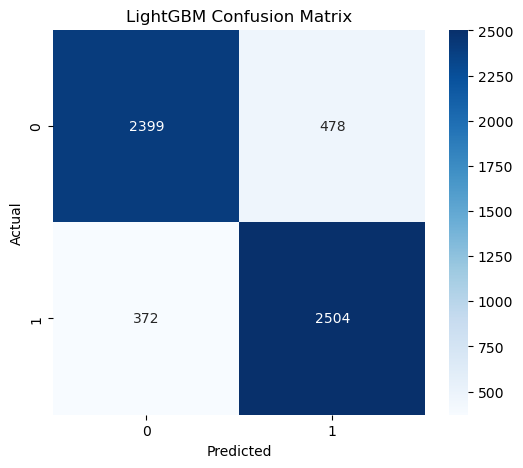

In [28]:
# Short LightGBM WITH Confusion Matrix
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
lgb.fit(X_train, y_train)

# Evaluate
preds = lgb.predict_proba(X_val)[:, 1]
preds_class = lgb.predict(X_val)

auc = roc_auc_score(y_val, preds)
acc = accuracy_score(y_val, preds_class)

print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, preds_class)
print(f"\nConfusion Matrix:\n{cm}")

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save predictions
pd.DataFrame({
    'enrollee_id': test['enrollee_id'],
    'target': lgb.predict_proba(test_encoded)[:, 1]
}).to_csv('lgbm_predictions.csv', index=False)

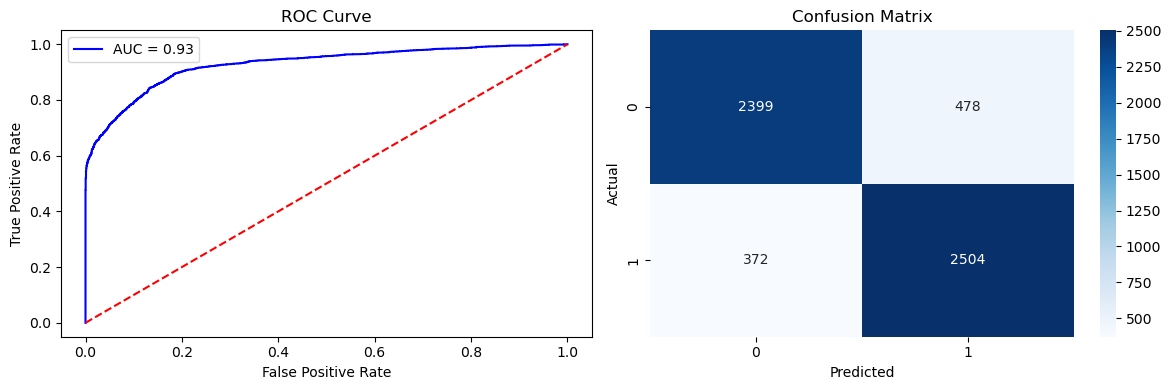

In [29]:
# 9. Minimal Visualization of model 
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, preds)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, 'b-', label=f'AUC = {roc_auc_score(y_val, preds):.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_val, preds_class), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

6